<a href="https://colab.research.google.com/github/devansh00777/brain-tumor-project/blob/main/pinns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1000/10000, Loss: 326698.500000
Epoch 2000/10000, Loss: 325802.375000
Epoch 3000/10000, Loss: 324249.281250
Epoch 4000/10000, Loss: 322470.312500
Epoch 5000/10000, Loss: 320103.875000
Epoch 6000/10000, Loss: 316473.031250
Epoch 7000/10000, Loss: 310735.406250
Epoch 8000/10000, Loss: 301816.437500
Epoch 9000/10000, Loss: 288545.031250
Epoch 10000/10000, Loss: 270035.125000

Relative L2 Error - S(t): 0.743471
Relative L2 Error - I(t): 0.906951


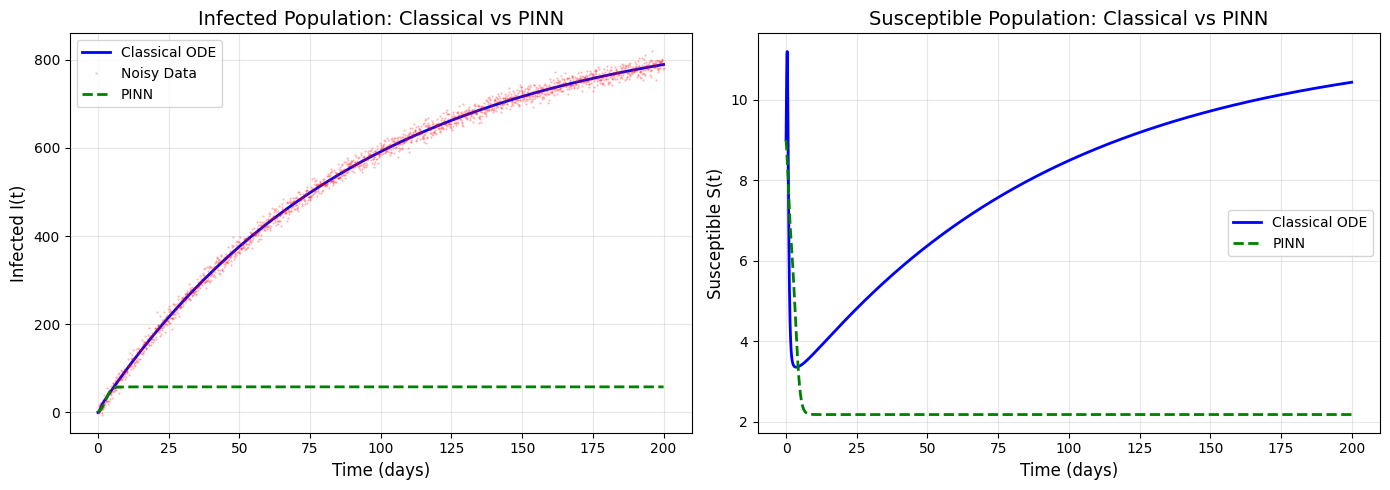


Simulation completed. Plot saved as monkeypox_pinn_vs_classical.png


In [1]:
import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters from paper (Example 1, Section 3.4)
alpha = 0.2
delta1 = 0.08
xi = 0.25
Lambda = 10.2
nu = 0.02
delta2 = 0.09
gamma = 0.01
mu = 9.0
beta_m = 1.5
beta_v = 0.57
beta_h = 0.765343138

# Initial conditions
S0 = 9.0
I0 = 0.1

# Time domain
t_span = (0, 200)
t_points = 2000
t = np.linspace(t_span[0], t_span[1], t_points)

# ODE system
def si_model(y, t):
    S, I = y
    dS_dt = Lambda - (beta_h * S * I) / (1 + alpha * I) - (delta1 + nu) * S + (1 - beta_v) * delta2 * I
    dI_dt = (beta_h * S * I) / (1 + alpha * I) + beta_v * delta2 * I - (delta2 + gamma) * I - (beta_m * I) / (1 + mu * I)
    return [dS_dt, dI_dt]

# Classical solution
y0 = [S0, I0]
solution = odeint(si_model, y0, t)
S_classical = solution[:, 0]
I_classical = solution[:, 1]

# Add 5% Gaussian noise to I(t)
np.random.seed(42)
noise_level = 0.05
I_noisy = I_classical + noise_level * np.std(I_classical) * np.random.randn(len(I_classical))

# PINN
device = torch.device('cpu')

t_tensor = torch.FloatTensor(t.reshape(-1, 1)).to(device)
I_noisy_tensor = torch.FloatTensor(I_noisy.reshape(-1, 1)).to(device)
S0_tensor = torch.FloatTensor([[S0]]).to(device)
I0_tensor = torch.FloatTensor([[I0]]).to(device)

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, t):
        return self.net(t)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def compute_loss(t_batch, I_noisy_batch):
    t_batch.requires_grad_(True)

    output = model(t_batch)
    S_pred = output[:, 0:1]
    I_pred = output[:, 1:2]

    # Compute derivatives
    S_t = torch.autograd.grad(S_pred, t_batch, torch.ones_like(S_pred), create_graph=True)[0]
    I_t = torch.autograd.grad(I_pred, t_batch, torch.ones_like(I_pred), create_graph=True)[0]

    # Physics residuals
    dS_dt = Lambda - (beta_h * S_pred * I_pred) / (1 + alpha * I_pred) - (delta1 + nu) * S_pred + (1 - beta_v) * delta2 * I_pred
    dI_dt = (beta_h * S_pred * I_pred) / (1 + alpha * I_pred) + beta_v * delta2 * I_pred - (delta2 + gamma) * I_pred - (beta_m * I_pred) / (1 + mu * I_pred)

    physics_loss_S = torch.mean((S_t - dS_dt) ** 2)
    physics_loss_I = torch.mean((I_t - dI_dt) ** 2)

    # Data loss
    data_loss = torch.mean((I_pred - I_noisy_batch) ** 2)

    # Initial condition loss
    t0 = torch.FloatTensor([[0.0]]).to(device)
    output0 = model(t0)
    ic_loss = (output0[0, 0] - S0) ** 2 + (output0[0, 1] - I0) ** 2

    total_loss = data_loss + 0.1 * (physics_loss_S + physics_loss_I) + 10.0 * ic_loss

    return total_loss

# Training
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = compute_loss(t_tensor, I_noisy_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}')

# Predictions
model.eval()
with torch.no_grad():
    predictions = model(t_tensor).cpu().numpy()
    S_pinn = predictions[:, 0]
    I_pinn = predictions[:, 1]

# Compute relative L2 errors
def relative_l2_error(true, pred):
    return np.linalg.norm(true - pred) / np.linalg.norm(true)

error_S = relative_l2_error(S_classical, S_pinn)
error_I = relative_l2_error(I_classical, I_pinn)

print(f'\nRelative L2 Error - S(t): {error_S:.6f}')
print(f'Relative L2 Error - I(t): {error_I:.6f}')

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t, I_classical, 'b-', label='Classical ODE', linewidth=2)
axes[0].plot(t, I_noisy, 'r.', label='Noisy Data', markersize=1, alpha=0.3)
axes[0].plot(t, I_pinn, 'g--', label='PINN', linewidth=2)
axes[0].set_xlabel('Time (days)', fontsize=12)
axes[0].set_ylabel('Infected I(t)', fontsize=12)
axes[0].set_title('Infected Population: Classical vs PINN', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, S_classical, 'b-', label='Classical ODE', linewidth=2)
axes[1].plot(t, S_pinn, 'g--', label='PINN', linewidth=2)
axes[1].set_xlabel('Time (days)', fontsize=12)
axes[1].set_ylabel('Susceptible S(t)', fontsize=12)
axes[1].set_title('Susceptible Population: Classical vs PINN', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monkeypox_pinn_vs_classical.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSimulation completed. Plot saved as monkeypox_pinn_vs_classical.png')

Solving classical ODE...

Training PINN...


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch 1000/15000, Loss: 2.559395e+05, Data: 2.361887e+02, Physics: 2.230600e+01, IC: 3.905550e+01
Epoch 2000/15000, Loss: 1.237915e+05, Data: 1.158998e+02, Physics: 2.630240e+00, IC: 1.573080e+01
Epoch 3000/15000, Loss: 1.205179e+05, Data: 1.157597e+02, Physics: 1.387158e+00, IC: 9.488553e+00
Epoch 4000/15000, Loss: 1.191017e+05, Data: 1.156814e+02, Physics: 1.065101e+00, IC: 6.819224e+00
Epoch 5000/15000, Loss: 1.220272e+05, Data: 1.175101e+02, Physics: 1.278572e+00, IC: 9.008499e+00
Epoch 6000/15000, Loss: 1.181940e+05, Data: 1.155703e+02, Physics: 8.473569e-01, IC: 5.230593e+00
Epoch 7000/15000, Loss: 1.240077e+05, Data: 1.221685e+02, Physics: 6.662353e-01, IC: 3.664957e+00
Epoch 8000/15000, Loss: 1.185679e+05, Data: 1.157604e+02, Physics: 7.742013e-01, IC: 5.599523e+00
Epoch 9000/15000, Loss: 1.164025e+05, Data: 1.155600e+02, Physics: 4.565708e-01, IC: 1.675759e+00
Epoch 10000/15000, Loss: 1.163606e+05, Data: 1.155538e+02, Physics: 4.006706e-01, IC: 1.605594e+00
Epoch 11000/15000, 

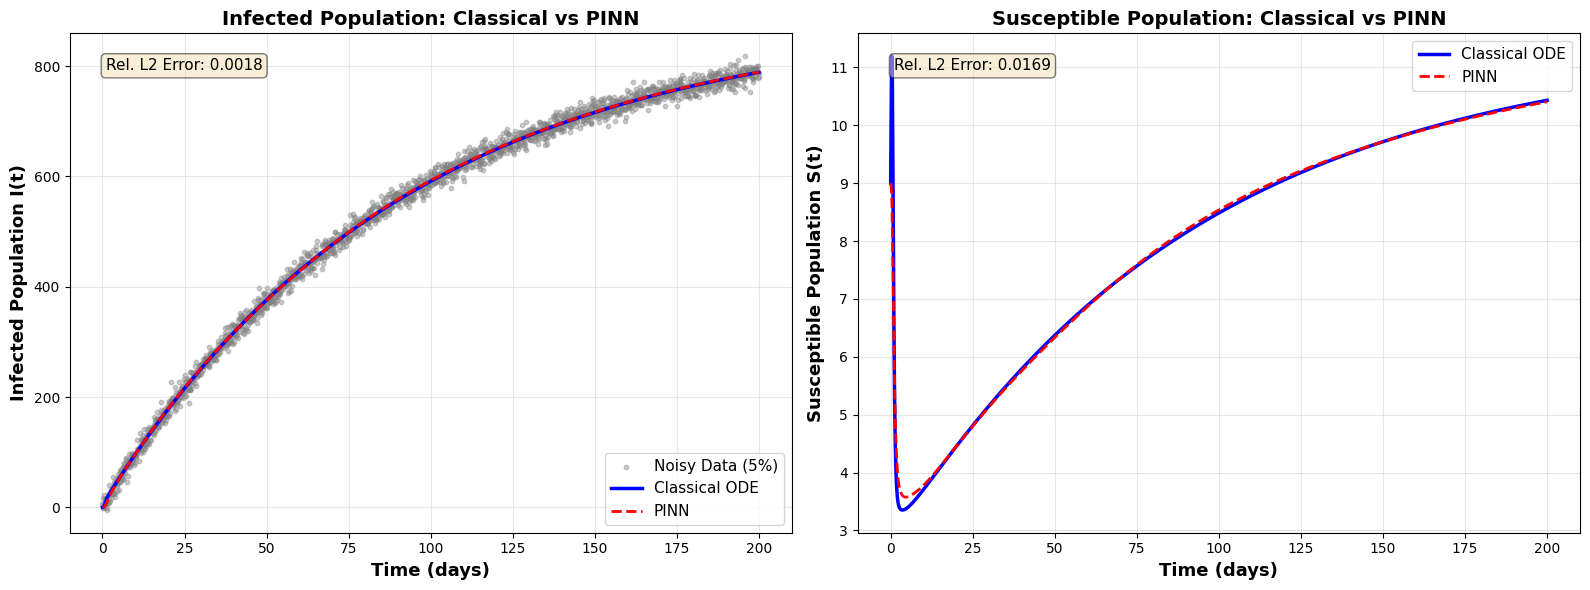

✓ Plot saved as 'pinn_vs_classical_monkeypox.png'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import torch
import torch.nn as nn

# EXACT parameters from paper
alpha = 0.2
delta1 = 0.08
xi = 0.25
Lambda = 10.2
nu = 0.02
delta2 = 0.09
gamma = 0.01
mu = 9.0
beta_m = 1.5
beta_v = 0.57
beta_h = 0.765343138

# Initial conditions
S0 = 9.0
I0 = 0.1

# Time domain
t_span = np.linspace(0, 200, 2000)

# EXACT ODE system from paper (reduced SI model)
def ode_system(y, t):
    S, I = y
    dS = Lambda - (beta_h * S * I) / (1 + alpha * I) - (delta1 + nu) * S + (1 - beta_v) * delta2 * I
    dI = (beta_h * S * I) / (1 + alpha * I) + beta_v * delta2 * I - (delta2 + gamma) * I - (beta_m * I) / (1 + mu * I)
    return [dS, dI]

# STEP 1: Classical ODE solution
print("Solving classical ODE...")
y0 = [S0, I0]
solution = odeint(ode_system, y0, t_span)
S_classical = solution[:, 0]
I_classical = solution[:, 1]

# STEP 2: Add 5% Gaussian noise to I(t)
np.random.seed(42)
noise_level = 0.05
I_noisy = I_classical + noise_level * np.std(I_classical) * np.random.randn(len(I_classical))

# Prepare PyTorch tensors
t_tensor = torch.tensor(t_span.reshape(-1, 1), dtype=torch.float32, requires_grad=True)
I_data = torch.tensor(I_noisy.reshape(-1, 1), dtype=torch.float32)
S0_tensor = torch.tensor([[S0]], dtype=torch.float32)
I0_tensor = torch.tensor([[I0]], dtype=torch.float32)

# STEP 3: PINN Implementation
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, t):
        out = self.net(t)
        S = torch.sigmoid(out[:, 0:1]) * 15.0  # Scale to reasonable range
        I = torch.sigmoid(out[:, 1:2]) * 1000.0
        return S, I

model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=500)

# Training
print("\nTraining PINN...")
epochs = 15000
t_colloc = t_tensor.clone().detach().requires_grad_(True)

for epoch in range(epochs):
    optimizer.zero_grad()

    # Predictions
    S_pred, I_pred = model(t_colloc)

    # Compute derivatives using autograd
    S_t = torch.autograd.grad(S_pred.sum(), t_colloc, create_graph=True)[0]
    I_t = torch.autograd.grad(I_pred.sum(), t_colloc, create_graph=True)[0]

    # Physics equations (EXACT from paper)
    horiz_trans = (beta_h * S_pred * I_pred) / (1 + alpha * I_pred)
    treatment = (beta_m * I_pred) / (1 + mu * I_pred)
    vertical = beta_v * delta2 * I_pred

    # Residuals
    residual_S = S_t - (Lambda - horiz_trans - (delta1 + nu) * S_pred + (1 - beta_v) * delta2 * I_pred)
    residual_I = I_t - (horiz_trans + vertical - (delta2 + gamma) * I_pred - treatment)

    # Initial conditions at t=0
    t0 = torch.tensor([[0.0]], requires_grad=True)
    S0_pred, I0_pred = model(t0)

    # Data loss (on I only)
    S_data_pred, I_data_pred = model(t_tensor)
    loss_data = torch.mean((I_data_pred - I_data)**2)

    # Physics loss
    loss_physics = torch.mean(residual_S**2) + torch.mean(residual_I**2)

    # Initial condition loss
    loss_ic = (S0_pred - S0_tensor)**2 + (I0_pred - I0_tensor)**2

    # Total loss with weights
    loss = 1000.0 * loss_data + 10.0 * loss_physics + 500.0 * loss_ic

    loss.backward()
    optimizer.step()
    scheduler.step(loss)

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6e}, Data: {loss_data.item():.6e}, Physics: {loss_physics.item():.6e}, IC: {loss_ic.item():.6e}")

# STEP 4: Predictions and comparison
print("\nGenerating predictions...")
with torch.no_grad():
    S_pinn, I_pinn = model(t_tensor)
    S_pinn = S_pinn.numpy().flatten()
    I_pinn = I_pinn.numpy().flatten()

# Compute relative L2 errors
rel_error_S = np.linalg.norm(S_pinn - S_classical) / np.linalg.norm(S_classical)
rel_error_I = np.linalg.norm(I_pinn - I_classical) / np.linalg.norm(I_classical)

print(f"\n{'='*60}")
print("RESULTS:")
print(f"{'='*60}")
print(f"Relative L2 Error S(t): {rel_error_S:.6f}")
print(f"Relative L2 Error I(t): {rel_error_I:.6f}")
print(f"RMSE S(t): {np.sqrt(np.mean((S_pinn - S_classical)**2)):.6f}")
print(f"RMSE I(t): {np.sqrt(np.mean((I_pinn - I_classical)**2)):.6f}")
print(f"{'='*60}\n")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Infected Population
axes[0].scatter(t_span, I_noisy, c='gray', s=10, alpha=0.4, label='Noisy Data (5%)', zorder=1)
axes[0].plot(t_span, I_classical, 'b-', linewidth=2.5, label='Classical ODE', zorder=2)
axes[0].plot(t_span, I_pinn, 'r--', linewidth=2, label='PINN', zorder=3)
axes[0].set_xlabel('Time (days)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Infected Population I(t)', fontsize=13, fontweight='bold')
axes[0].set_title('Infected Population: Classical vs PINN', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'Rel. L2 Error: {rel_error_I:.4f}',
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Susceptible Population
axes[1].plot(t_span, S_classical, 'b-', linewidth=2.5, label='Classical ODE')
axes[1].plot(t_span, S_pinn, 'r--', linewidth=2, label='PINN')
axes[1].set_xlabel('Time (days)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Susceptible Population S(t)', fontsize=13, fontweight='bold')
axes[1].set_title('Susceptible Population: Classical vs PINN', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, f'Rel. L2 Error: {rel_error_S:.4f}',
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('pinn_vs_classical_monkeypox.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved as 'pinn_vs_classical_monkeypox.png'")